In [1]:
import requests
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime, timedelta, timezone

In [2]:
import requests

url = "https://api.elections.kalshi.com/trade-api/v2/series?include_volume=true"

response = requests.get(url).json()
data = pd.DataFrame(response["series"])

In [3]:
volumes = data.sort_values("volume").volume
threshold = 5e6
sub_data = data[volumes > threshold]

/var/folders/b3/wb1ksqsd6tv5s9jff9pnm7hw0000gn/T/ipykernel_3647/793062082.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sub_data = data[volumes > threshold]


In [4]:
series_results = []
series_tickers = list(sub_data.ticker.unique())
for ticker in tqdm(series_tickers):
    # Gamma API endpoint for series details
    url = f"https://api.elections.kalshi.com/trade-api/v2/markets/"
    params = {"series_ticker":ticker, "include_volume": "true", "limit" : 1000}
    
    response = requests.get(url, params=params)
    data = response.json()
    series_results.append(data)


  0%|          | 0/359 [00:00<?, ?it/s]

100%|██████████| 359/359 [04:17<00:00,  1.39it/s]


In [5]:
all_ticker_data = []
for x in series_results:
    markets = x["markets"]
    for market in markets:
        all_ticker_data.append(market)
all_ticker_data = pd.DataFrame(all_ticker_data)

In [6]:
tickers_timing_data = all_ticker_data[["close_time", "created_time", "ticker"]].set_index("ticker")

In [12]:
now = pd.Timestamp.now(tz='UTC')
threshold_50d = now - pd.Timedelta(days=50)

tickers_timing_data['close_time'] = pd.to_datetime(tickers_timing_data['close_time'], format='ISO8601', utc=True)
tickers_timing_data['created_time'] = pd.to_datetime(tickers_timing_data['created_time'], format='ISO8601', utc=True)

mask = (tickers_timing_data['close_time'] > now) & (tickers_timing_data['created_time'] < threshold_50d)
tickers_timing_data_filtered = tickers_timing_data[mask].copy()

In [13]:
tickers_list = list(tickers_timing_data_filtered.index.unique())

In [14]:
# Configuration temporelle
end_ts = int(datetime.now().timestamp())
start_ts = int((datetime.now() - timedelta(days=50)).timestamp())
interval = 1440 # 1 jour en minutes

url = "https://api.elections.kalshi.com/trade-api/v2/markets/candlesticks"

all_candles = {}
batch_size = 100

# Boucle par lots de 100 tickers
for i in tqdm(range(0, len(tickers_list), batch_size)):
    batch = tickers_list[i : i + batch_size]
    
    params = {
        "market_tickers": ",".join(batch),
        "start_ts": start_ts,
        "end_ts": end_ts,
        "period_interval": interval,
        "include_latest_before_start": "false"
    }

    res = requests.get(url, params=params)
    data = res.json()

    for m in data.get("markets", []):
        ticker = m.get("market_ticker")
        candles = m.get("candlesticks", [])
        all_candles[ticker] = candles



100%|██████████| 13/13 [00:13<00:00,  1.07s/it]


In [15]:
rows = []
for ticker, candles in all_candles.items():
    for c in candles:
        # Merge top level with 'price' nested dict
        row = {
            "ticker": ticker,
            "ts": pd.to_datetime(c["end_period_ts"], unit="s", utc=True),
            "volume": c.get("volume"),
            **c.get("price", {})
        }
        rows.append(row)

df = pd.DataFrame(rows).set_index(["ts","ticker"]).sort_index().astype("float")

In [16]:
processed_df = pd.DataFrame()
processed_df['volatility_id'] = (df['high'] - df['low']) / df['open']
processed_df['return'] = df.groupby(level=0)['close'].pct_change()
processed_df['price_loc'] = (df['close'] - df['low']) / (df['high'] - df['low'] + 1e-9)
processed_df['body_ratio'] = np.abs(df['close'] - df['open']) / (df['high'] - df['low'] + 1e-9)
processed_df['dollar_volume'] = df['volume'] * df['mean_dollars']
processed_df['mean_dev'] = (df['close_dollars'] - df['mean_dollars']) / df['mean_dollars']

/var/folders/b3/wb1ksqsd6tv5s9jff9pnm7hw0000gn/T/ipykernel_3647/421528858.py:3: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  processed_df['return'] = df.groupby(level=0)['close'].pct_change()


In [17]:
lagged_frames = [
    processed_df.groupby(level=0).shift(i).add_suffix(f'_Lagged_{i}') 
    for i in range(4)
]

# Concatenate horizontally to get the final feature set
df_lagged = pd.concat(lagged_frames, axis=1)

In [18]:
y = df_lagged["return_Lagged_0"]
X = df_lagged.loc[:, ~df_lagged.columns.str.contains("0")]

In [19]:
import lightgbm as lgb
import numpy as np
import pandas as pd

X = X.sort_index(level=0)
y = y.loc[X.index]

days = X.index.get_level_values(0).unique().sort_values()
min_train_days = 10  # On attend d'avoir 10 jours de data avant de tester

results = []

# 2. Expanding Window Loop
for i in tqdm(range(min_train_days, len(days))):
    train_days = days[:i]
    test_day = days[i]
    
    # Split
    X_train = X[X.index.get_level_values(0).isin(train_days)]
    y_train = y[y.index.get_level_values(0).isin(train_days)]
    
    X_test = X[X.index.get_level_values(0) == test_day]
    y_test = y[y.index.get_level_values(0) == test_day]
    
    if len(X_train) < 50 or len(X_test) == 0:
        continue
        
    # 3. Fit Model
    model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, verbosity=-1)
    model.fit(X_train, y_train)
    
    # 4. Predict and Calculate PnL
    y_hat = model.predict(X_test)
    
    # Le PnL est le produit du signe de la prédiction par le retour réel
    # On simule une position longue si y_hat > 0 et courte si y_hat < 0
    daily_pnl = y_hat * y_test.values
    
    res_df = pd.DataFrame({
        'y_true': y_test.values,
        'y_hat': y_hat,
        'pnl': daily_pnl
    }, index=X_test.index)
    
    results.append(res_df)

# 5. Synthèse des résultats
final_df = pd.concat(results)
pnl_mat = final_df['pnl'].to_frame().reset_index().pivot(index = "ts", columns = "ticker", values = "pnl")

100%|██████████| 40/40 [00:17<00:00,  2.25it/s]


42.23613267081444

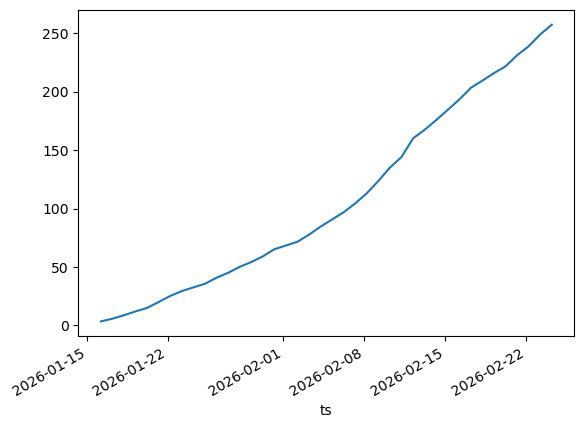

In [21]:
pnl = pnl_mat.mean(1)
pnl.cumsum().plot()
np.sqrt(365)*pnl.mean()/pnl.std()